In [44]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


In [45]:
files = [
    "../../course_assignments/homework10/M13_0001.fits",
    "../../course_assignments/homework10/M13_0002.fits",
    "../../course_assignments/homework10/M13_0003.fits",
    "../../course_assignments/homework10/M13_0004.fits",
    "../../course_assignments/homework10/M13_0005.fits"
]

data_list = []
for f in files:
    with fits.open(f) as hdul:
        data = hdul[0].data
        data_list.append(data)


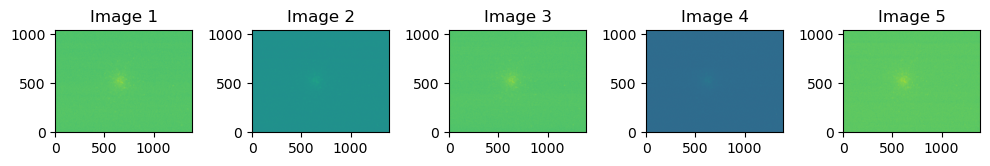

In [46]:
fig, axes = plt.subplots(1, 5, figsize=(10, 10))
for i, data in enumerate(data_list):
    axes[i].imshow(data, origin="lower")
    axes[i].set_title(f"Image {i+1}")


plt.tight_layout()
plt.show()

In [47]:
vmin = min(d.min() for d in data_list)
vmax = max(d.max() for d in data_list)


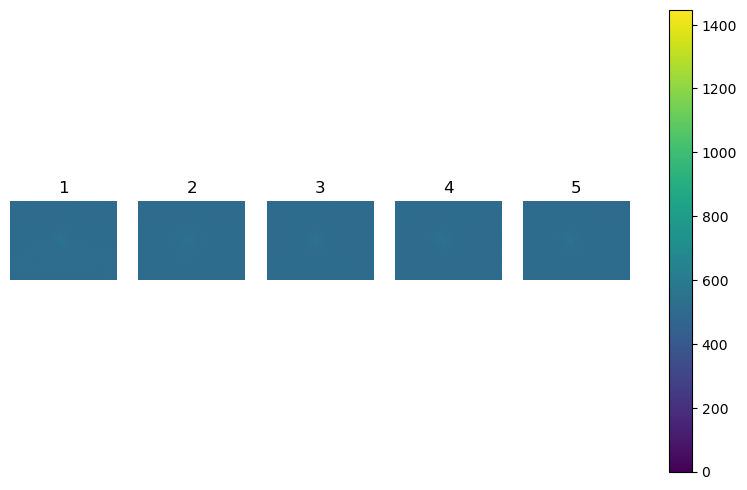

In [48]:
fig, axes = plt.subplots(1, 5, figsize=(10, 10))
for i, data in enumerate(data_list):
    im = axes[i].imshow(data, origin="lower", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"{i+1}")
    axes[i].axis('off')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.show()


In [49]:
#Fainter stars in the raw image became a little more visible 

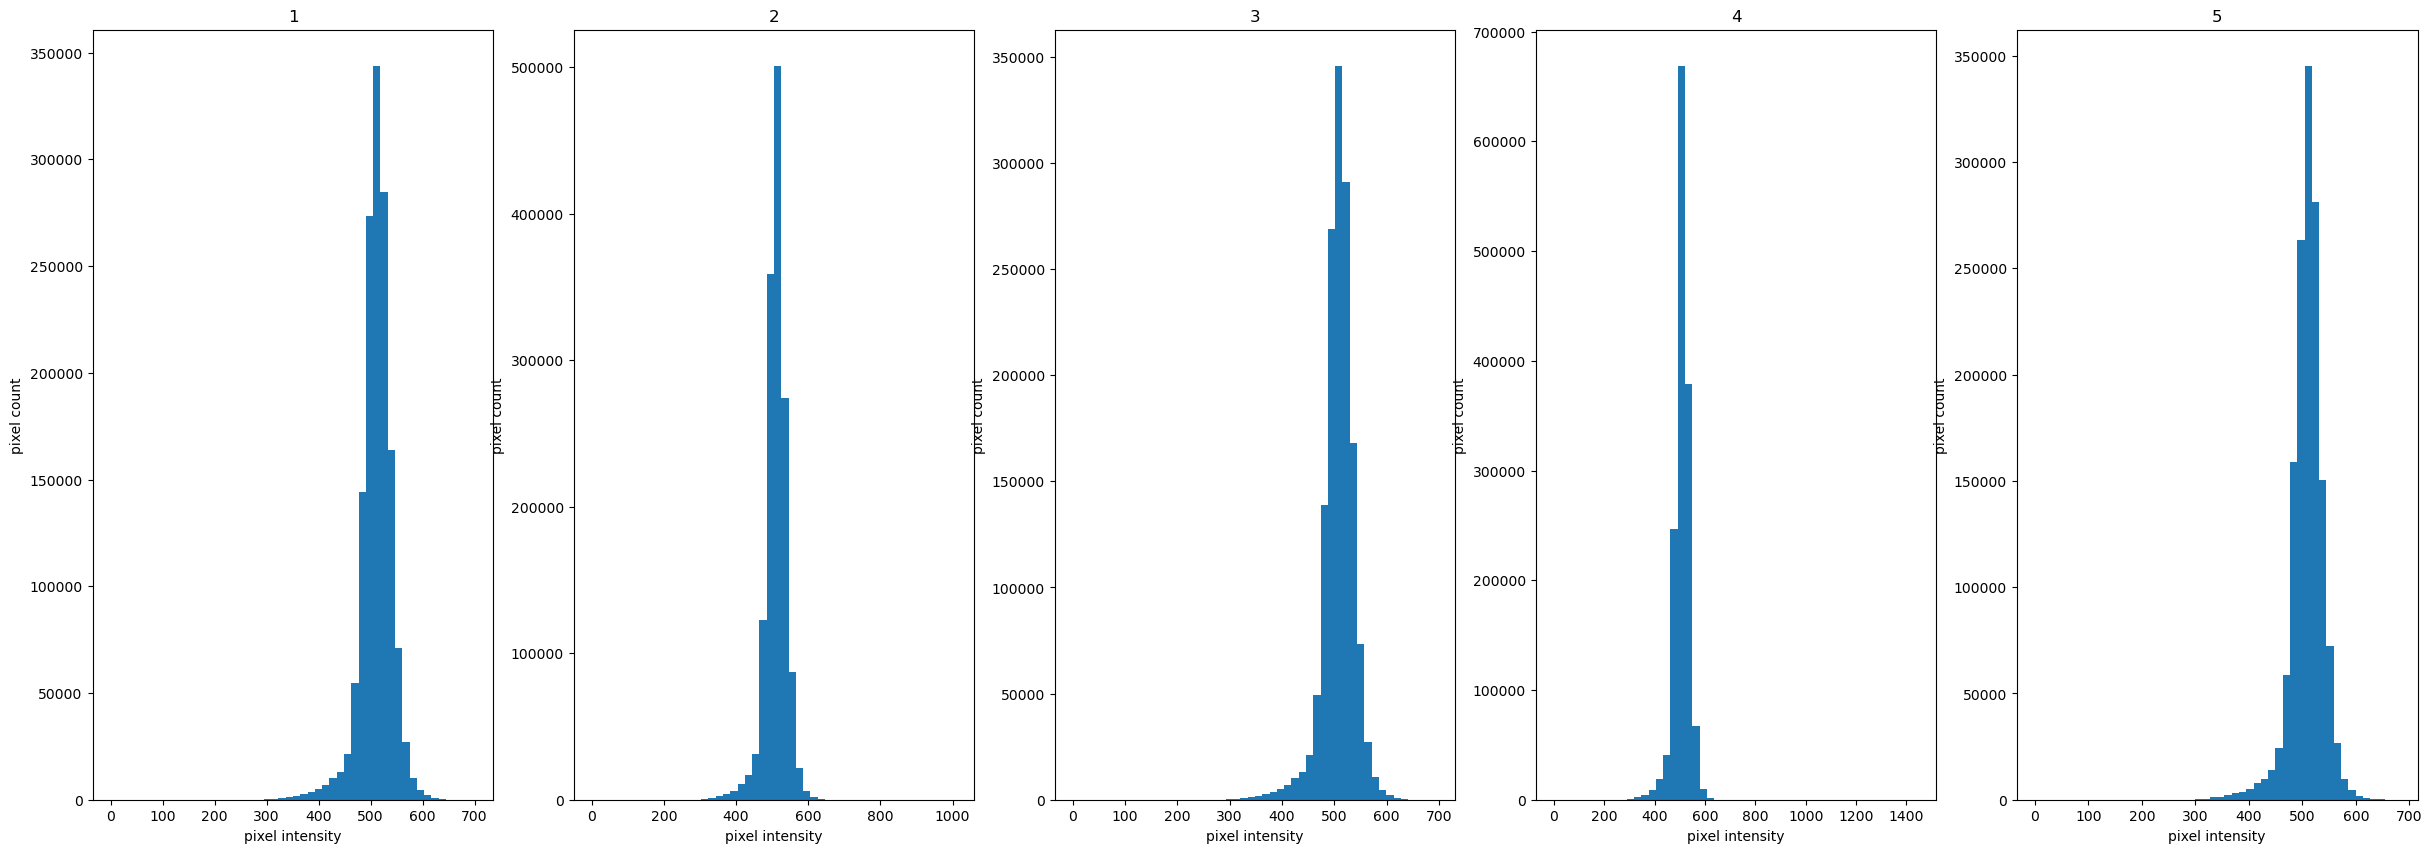

In [50]:
fig,axes = plt.subplots(1, 5, figsize=(30, 10))
for i, data in enumerate(data_list):
    axes[i].hist(data.ravel(), bins=50)
    axes[i].set_title(f"{i+1}")
    axes[i].set_xlabel("pixel intensity")
    axes[i].set_ylabel("pixel count")

plt.show()


In [51]:
#bins=50 divides the pixel range to 50 intervals
#most data is centered around 500 pixel intensity
#the data is not very spread out and is mostly around the center


In [52]:
for i, data in enumerate(data_list):
    print(f"{i+1}: mean = {np.mean(data):.1f}, median = {np.median(data):.1f}")


1: mean = 510.5, median = 512.0
2: mean = 509.7, median = 511.0
3: mean = 508.0, median = 510.0
4: mean = 507.9, median = 509.0
5: mean = 508.8, median = 510.0


In [53]:
stack = np.stack(data_list)  
combined_image = np.median(stack, axis=0)

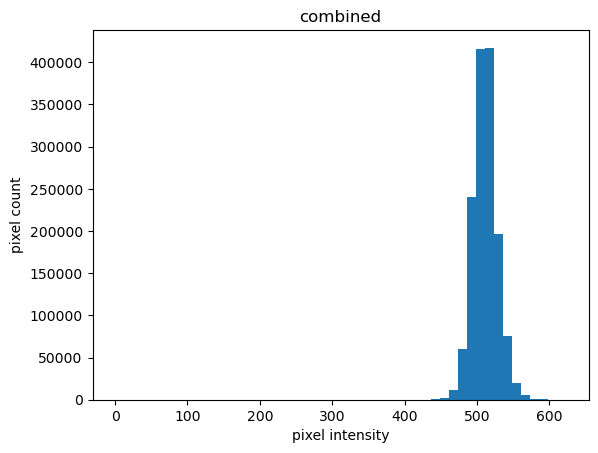

In [54]:
plt.hist(combined_image.ravel(), bins=50)
plt.title("combined")
plt.xlabel("pixel intensity")
plt.ylabel("pixel count")
plt.show()


In [55]:
vmin = np.percentile(combined_image, 5)
vmax = np.percentile(combined_image, 95)


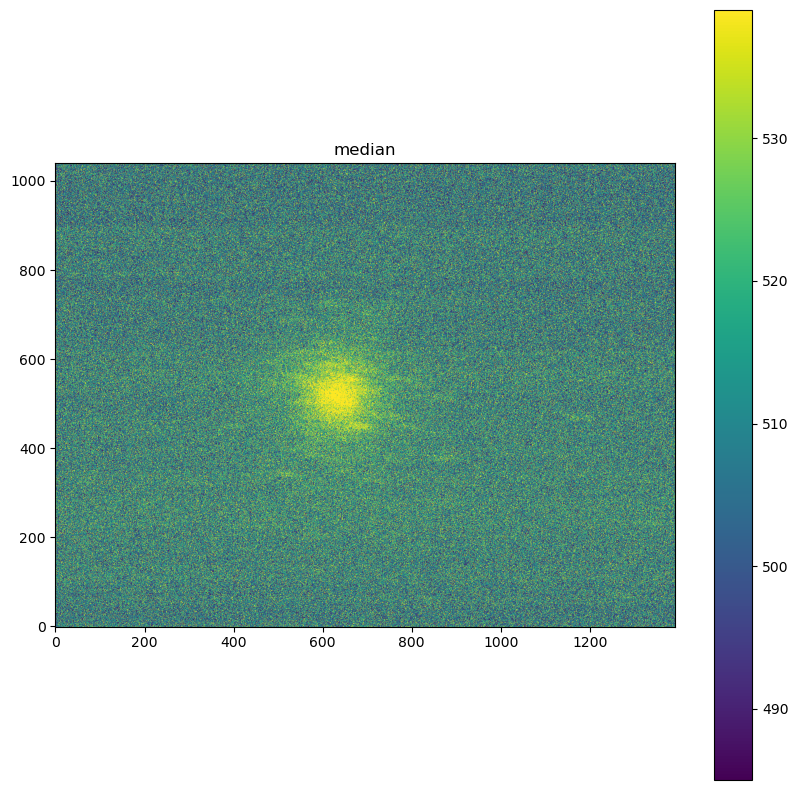

In [59]:
plt.figure(figsize=(10, 10))
plt.imshow(combined_image, origin="lower",vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("median")
plt.show()


In [60]:
#the combined image shows a much clearer image and background is smoother

In [61]:
fits.writeto("combined.fits", combined_image, overwrite=True)
